# GAN-Style (Surrogate) Augmentation + ElasticNet for FRDA Progression

A leakage-safe, subject-level cross-validated ElasticNet pipeline on progression-aware **delta features** (v2 − v1) and evaluate whether simple numpy/sklearn-based *conditional tabular GAN surrogates* (GMM/KDE sampling + MLP-based refinement/quality scoring) improves prediction of **ΔFARS** and **ΔSARA** on the Melbourne FRDA merged dataset.


In [1]:
# Imports and configuration
import os
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, LeaveOneGroupOut, KFold
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.neural_network import MLPClassifier, MLPRegressor

try:
    import matplotlib.pyplot as plt
    _HAS_MPL = True
except Exception as _e:
    plt = None
    _HAS_MPL = False
    print('WARNING: matplotlib failed to import; plotting disabled. Error:', repr(_e))

# Suppress only specific known-safe warnings; do NOT use blanket ignore
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, message='Coordinate descent without L1 regularization*')

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


BUNDLE_ROOT = Path('..').resolve()
os.chdir(BUNDLE_ROOT)
print('Working directory:', Path.cwd())

DATA_PATH = Path('data/processed/melbourne_frda_merged.csv')
OUT_DIR = Path('results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

AUG_RATIOS = [0, 1, 2, 5]
N_QUANTILE_BINS = 3

# Speed/quality tradeoff
# FAST_MODE=True uses smaller CV grids and disables MLP-based GAN refinement/discrimination
# so the full experiment finishes much faster.
FAST_MODE = True
ENET_L1_RATIOS_FAST = [0.0, 0.5, 1.0]
ENET_ALPHAS_FAST = np.logspace(-3, 1, 12)
ENET_INNER_FOLDS_FAST = 5

if _HAS_MPL:
    plt.rcParams.update({
        'figure.dpi': 120,
        'savefig.dpi': 150,
        'axes.grid': True,
        'grid.alpha': 0.3,
    })


Working directory: /Users/robertwang/Documents/New_project/baseline_composite_biomakers


In [2]:
# Data loading and dataset inspection
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing dataset at {DATA_PATH.resolve()}')

df_raw = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())

# Basic inspection
missing_frac = df_raw.isna().mean().sort_values(ascending=False)
print('Top missingness columns (fraction):')
display(missing_frac.head(12))

print('Dtypes summary:')
display(df_raw.dtypes.value_counts())


Loaded: data/processed/melbourne_frda_merged.csv
Shape: (26, 69)


,ID,SCP_v1,SCP_v2,MCP_v1,MCP_v2,ICP_v1,ICP_v2,Midbrain_v1,Midbrain_v2,Pons_v1,...,dur1,dur2,GAA1,GAA2,SARA1,SARA2,FARS1,FARS2,cohort,subject_id
0,sub-melfrd003,0.21930,0.18100,3.41675,3.18325,0.97095,0.84415,5994.24,6025.21,12362.1,...,18.5,20.416667,713.0,875.0,25.0,31.5,101.5,116.0,melb,sub-melfrd003
1,sub-melfrd004,0.22745,0.23620,3.67430,3.68980,1.00900,1.09200,6180.96,6048.20,13212.0,...,13.7,15.583333,747.0,875.0,22.0,28.0,92.5,104.0,melb,sub-melfrd004
2,sub-melfrd005,0.18545,0.15415,3.20745,3.05465,0.88980,0.85390,4999.48,4809.56,11303.2,...,16.2,18.166667,998.0,998.0,19.5,20.0,96.5,102.0,melb,sub-melfrd005
3,sub-melfrd006,0.19315,0.14570,3.47420,3.38585,0.94880,0.89995,5195.23,5168.61,11662.7,...,9.0,10.750000,837.0,877.0,25.0,30.5,100.0,109.5,melb,sub-melfrd006
4,sub-melfrd008,0.23160,0.23905,3.40450,3.33090,1.00790,1.01605,5558.25,5424.53,11967.8,...,9.6,11.416667,569.0,884.0,22.5,28.5,77.0,96.0,melb,sub-melfrd008


Top missingness columns (fraction):


SARA2        0.115385
ID           0.000000
RDMCP_v1     0.000000
ECC_C2_v1    0.000000
ECC_C1_v2    0.000000
ECC_C1_v1    0.000000
RDICP_v2     0.000000
RDICP_v1     0.000000
RDMCP_v2     0.000000
RDSCP_v2     0.000000
CSA_C1_v1    0.000000
RDSCP_v1     0.000000
dtype: float64

Dtypes summary:


float64    66
str         3
Name: count, dtype: int64

In [3]:
# Column mapping and target discovery — auto-detect FARS/SARA columns
def _norm(s: str) -> str:
    return str(s).strip().lower()

def find_subject_id_column(df: pd.DataFrame) -> str:
    # Prefer explicit subject id columns if present
    candidates = ['subject_id', 'subject', 'subjid', 'participant_id', 'participant', 'id']
    cols_norm = {_norm(c): c for c in df.columns}
    for key in candidates:
        if key in cols_norm:
            return cols_norm[key]
    # Fallback heuristic: a column with all/mostly unique values
    best = None
    best_score = -1
    n = len(df)
    for c in df.columns:
        nunq = df[c].nunique(dropna=True)
        score = nunq / max(n, 1)
        if score > best_score and nunq >= max(3, int(0.5 * n)):
            best = c
            best_score = score
    if best is None:
        raise KeyError('Could not infer subject id column')
    return best

def find_target_pairs(df: pd.DataFrame):
    # Return dict target_name -> (col_v1, col_v2)
    cols = list(df.columns)
    cols_norm = {_norm(c): c for c in cols}

    def find_pair(prefix: str):
        # Prefer exact prefix1/prefix2
        c1 = None
        c2 = None
        for pat1 in [f'{prefix}1', f'{prefix}_v1', f'{prefix}v1']:
            if pat1 in cols_norm:
                c1 = cols_norm[pat1]
                break
        for pat2 in [f'{prefix}2', f'{prefix}_v2', f'{prefix}v2']:
            if pat2 in cols_norm:
                c2 = cols_norm[pat2]
                break
        # Fallback: fuzzy contains + endswith 1/2
        if c1 is None or c2 is None:
            prefix_l = prefix.lower()
            cands = [c for c in cols if prefix_l in _norm(c)]
            for c in cands:
                cn = _norm(c)
                if cn.endswith('1') or cn.endswith('_v1'):
                    c1 = c1 or c
                if cn.endswith('2') or cn.endswith('_v2'):
                    c2 = c2 or c
        if c1 is None or c2 is None:
            return None
        return (c1, c2)

    targets = {}
    for t in ['SARA', 'FARS']:
        pair = find_pair(t)
        if pair is not None:
            targets[t] = pair
    if not targets:
        raise KeyError('Could not auto-detect SARA/FARS target columns')
    return targets

def find_paired_feature_columns(df: pd.DataFrame, exclude_cols=None):
    exclude_cols = set(exclude_cols or [])
    pairs = {}
    cols = list(df.columns)
    cols_set = set(cols)

    # Pattern A: *_v1 / *_v2
    for c in cols:
        if c in exclude_cols:
            continue
        if c.endswith('_v1'):
            base = c[:-3]
            c2 = base + '_v2'
            if c2 in cols_set and c2 not in exclude_cols:
                pairs[base] = (c, c2)

    # Pattern B disabled: heuristic *1/*2 pairing is semantically unsafe
    # (e.g. GAA1/GAA2 are allele counts, not visit timepoints).
    # Only strictly *_v1/*_v2 pairs (Pattern A) are treated as longitudinal.

    return pairs

subject_col = find_subject_id_column(df_raw)
target_pairs = find_target_pairs(df_raw)

exclude_for_features = {subject_col, 'cohort'}
exclude_for_features |= set(sum([list(v) for v in target_pairs.values()], []))

feature_pairs = find_paired_feature_columns(df_raw, exclude_cols=exclude_for_features)

print('Subject column:', subject_col)
print('Targets detected:')
for t, (c1, c2) in target_pairs.items():
    print(f'  {t}: {c1} -> {c2}')
print('Paired feature bases found:', len(feature_pairs))
print('Example paired bases:', list(feature_pairs.keys())[:12])


Subject column: subject_id
Targets detected:
  SARA: SARA1 -> SARA2
  FARS: FARS1 -> FARS2
Paired feature bases found: 27
Example paired bases: ['SCP', 'MCP', 'ICP', 'Midbrain', 'Pons', 'Medulla', 'AntCBLM', 'SupPostCBLM', 'InfPostCBLM', 'FlocCBLM', 'VermisCBLM', 'FASCP']


In [4]:
# Progression-aware representation — compute delta features: v2 minus v1 per subject
def coerce_numeric_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(s, errors='coerce')

df = df_raw.copy()

# Ensure subject col is treated as string group key
df[subject_col] = df[subject_col].astype(str)
groups = df[subject_col].values

# Delta features
delta_features = {}
for base, (c1, c2) in feature_pairs.items():
    s1 = coerce_numeric_series(df[c1])
    s2 = coerce_numeric_series(df[c2])
    delta_features[f'{base}_delta'] = (s2 - s1)

X_delta_df = pd.DataFrame(delta_features)

# Encode sex if present (no v1/v2): keep as baseline static covariate
static_covariates = []
if 'sex' in df.columns:
    # Common encodings: M/F, 0/1, etc.
    sex_raw = df['sex'].astype(str).str.strip().str.lower()
    sex_map = {'m': 1.0, 'male': 1.0, '1': 1.0, 'f': 0.0, 'female': 0.0, '0': 0.0}
    df['_sex_bin'] = sex_raw.map(sex_map)
    static_covariates.append('_sex_bin')

X_static_df = df[static_covariates].copy() if static_covariates else pd.DataFrame(index=df.index)

X_df = pd.concat([X_delta_df, X_static_df], axis=1)

# Delta targets
y_delta = {}
for t, (c1, c2) in target_pairs.items():
    y_delta[f'd{t}'] = coerce_numeric_series(df[c2]) - coerce_numeric_series(df[c1])
y_df = pd.DataFrame(y_delta)

print('X_df shape:', X_df.shape)
print('y_df shape:', y_df.shape)
display(X_df.head())
display(y_df.head())

# Feature domains (lightweight, keyword-based) for optional domain-combination experiments
def build_feature_domains(columns):
    cols = list(columns)
    domains = {}
    def add(name, pred):
        sel = [c for c in cols if pred(c)]
        if len(sel) >= 3:
            domains[name] = sel

    add('dti_fa', lambda c: c.lower().startswith('fa') or '_fa' in c.lower())
    add('dti_md', lambda c: c.lower().startswith('md') or '_md' in c.lower())
    add('dti_ad', lambda c: c.lower().startswith('ad') or '_ad' in c.lower())
    add('dti_rd', lambda c: c.lower().startswith('rd') or '_rd' in c.lower())
    add('spinal', lambda c: c.lower().startswith('ecc_') or c.lower().startswith('csa_'))
    add('brainstem', lambda c: any(k in c.lower() for k in ['midbrain', 'pons', 'medulla', 'scp', 'mcp', 'icp']))
    add('cerebellum', lambda c: any(k in c.lower() for k in ['cblm', 'vermis', 'floc']))
    # demographics only added if _sex_bin actually has valid values (checked at runtime via X_df)
    return domains

feature_domains = build_feature_domains(X_df.columns)
print('Domains discovered:', sorted(feature_domains.keys()))
for k, v in feature_domains.items():
    print(f'  {k}: {len(v)} features')


X_df shape: (26, 28)
y_df shape: (26, 2)


,SCP_delta,MCP_delta,ICP_delta,Midbrain_delta,Pons_delta,Medulla_delta,AntCBLM_delta,SupPostCBLM_delta,InfPostCBLM_delta,FlocCBLM_delta,...,ADMCP_delta,ADICP_delta,RDSCP_delta,RDMCP_delta,RDICP_delta,ECC_C1_delta,ECC_C2_delta,CSA_C1_delta,CSA_C2_delta,_sex_bin
0,-0.03830,-0.23350,-0.12680,30.97,-739.4,-759.25,-705.63,-5777.62,-1693.16,-78.397,...,-1.253100e-04,0.000162,-0.000226,-0.000111,0.000139,-0.004450,-0.008550,-2.544072,-2.428276,NaN
1,0.00875,0.01550,0.08300,-132.76,-213.1,-104.70,-318.33,-1040.52,266.20,-77.298,...,1.400000e-07,0.000075,-0.000098,-0.000017,0.000023,0.000209,0.004486,1.047113,0.608276,NaN
2,-0.03130,-0.15280,-0.03590,-189.92,-601.9,-81.31,8.42,-890.30,-519.42,-5.284,...,-3.040000e-06,0.000105,-0.000016,0.000030,0.000076,0.009749,-0.022761,-2.062001,1.246471,NaN
3,-0.04745,-0.08835,-0.04885,-26.62,-513.2,-173.56,-172.82,-2130.33,-53.22,0.394,...,8.200000e-06,-0.000041,-0.000030,0.000044,0.000082,0.059013,0.000294,-1.912974,-1.489385,NaN
4,0.00745,-0.07360,0.00815,-133.72,-304.7,12.38,-251.46,-245.18,-436.94,-10.117,...,2.325000e-05,-0.000008,-0.000006,0.000056,-0.000063,0.024033,-0.036063,-5.164576,-0.374369,NaN


,dSARA,dFARS
0,6.5,14.5
1,6.0,11.5
2,0.5,5.5
3,5.5,9.5
4,6.0,19.0


Domains discovered: ['brainstem', 'cerebellum', 'dti_ad', 'dti_fa', 'dti_md', 'dti_rd', 'spinal']
  dti_fa: 3 features
  dti_md: 3 features
  dti_ad: 3 features
  dti_rd: 3 features
  spinal: 4 features
  brainstem: 18 features
  cerebellum: 5 features


In [5]:
# GAN design — numpy-based small conditional tabular GAN (surrogate)
# Approach (small-n practical):
# 1) Condition on target quantile bins (e.g., low/med/high progression).
# 2) Sample X from per-bin GaussianMixture (fallback to single Gaussian).
# 3) Optionally refine X with a denoising MLPRegressor trained only on train data.
# 4) Optionally score/filter synthetic samples with an MLPClassifier discriminator.

class QuantileBinner:
    def __init__(self, n_bins=3):
        self.n_bins = int(n_bins)
        self.edges_ = None

    def fit(self, y):
        y = np.asarray(y, dtype=float)
        if len(np.unique(y[~np.isnan(y)])) < self.n_bins:
            # Degenerate case: use min/max with small jitter
            y0 = y[~np.isnan(y)]
            if len(y0) == 0:
                self.edges_ = np.array([-np.inf, np.inf])
                return self
            mn, mx = float(np.min(y0)), float(np.max(y0))
            if mn == mx:
                self.edges_ = np.array([-np.inf, mn, np.inf])
            else:
                self.edges_ = np.quantile(y0, np.linspace(0, 1, self.n_bins + 1))
                self.edges_[0] = -np.inf
                self.edges_[-1] = np.inf
            return self
        qs = np.linspace(0, 1, self.n_bins + 1)
        edges = np.quantile(y[~np.isnan(y)], qs)
        edges[0] = -np.inf
        edges[-1] = np.inf
        # Ensure strictly increasing edges
        for i in range(1, len(edges)):
            if edges[i] <= edges[i-1]:
                edges[i] = edges[i-1] + 1e-6
        self.edges_ = edges
        return self

    def transform(self, y):
        if self.edges_ is None:
            raise RuntimeError('QuantileBinner not fit')
        y = np.asarray(y, dtype=float)
        # bins: 0..n_bins-1
        b = np.digitize(y, self.edges_[1:-1], right=False)
        return b


class ConditionalGMM:
    def __init__(self, n_components_max=3, reg_covar=1e-6, random_state=42):
        self.n_components_max = int(n_components_max)
        self.reg_covar = float(reg_covar)
        self.random_state = int(random_state)
        self.models_ = {}
        self.means_ = {}
        self.covs_ = {}

    def fit(self, X, bins):
        X = np.asarray(X, dtype=float)
        # Impute NaN column-wise with median before GMM fitting
        import warnings as _warnings
        with _warnings.catch_warnings():
            _warnings.filterwarnings('ignore', message='All-NaN slice encountered')
            col_medians = np.nanmedian(X, axis=0)
        col_medians = np.where(np.isnan(col_medians), 0.0, col_medians)
        nan_mask = np.isnan(X)
        X_imp = X.copy()
        X_imp[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
        X = X_imp
        bins = np.asarray(bins, dtype=int)
        self.col_medians_ = col_medians  # store for use in sample imputation
        self.models_.clear()
        self.means_.clear()
        self.covs_.clear()
        for b in np.unique(bins):
            Xb = X[bins == b]
            # Fallback if too few samples
            if Xb.shape[0] < 4:
                mu = np.nanmean(Xb, axis=0)
                # diagonal covariance fallback
                sig = np.nanstd(Xb, axis=0)
                cov = np.diag(np.maximum(sig, 1e-3) ** 2)
                self.models_[int(b)] = None
                self.means_[int(b)] = mu
                self.covs_[int(b)] = cov
                continue
            n_comp = min(self.n_components_max, max(1, Xb.shape[0] // 3))
            gm = GaussianMixture(
                n_components=n_comp,
                covariance_type='full',
                reg_covar=self.reg_covar,
                random_state=self.random_state,
                max_iter=300,
            )
            gm.fit(Xb)
            self.models_[int(b)] = gm
        return self

    def sample(self, n, b, rng):
        n = int(n)
        b = int(b)
        if n <= 0:
            return np.zeros((0, 0))
        if b not in self.models_:
            raise KeyError(f'Bin {b} not fitted')
        gm = self.models_[b]
        if gm is None:
            mu = self.means_[b]
            cov = self.covs_[b]
            return rng.multivariate_normal(mean=mu, cov=cov, size=n)
        Xs, _ = gm.sample(n_samples=n)
        return Xs


class DenoisingRefinerMLP:
    def __init__(self, hidden_layer_sizes=(64, 64), alpha=1e-3, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = float(alpha)
        self.random_state = int(random_state)
        self.model_ = None
        self.noise_scale_ = None
    def fit(self, X, rng):
        X = np.asarray(X, dtype=float)
        # Impute NaNs (MLPRegressor cannot train on NaNs)
        import warnings as _warnings
        with _warnings.catch_warnings():
            _warnings.filterwarnings('ignore', message='All-NaN slice encountered')
            col_medians = np.nanmedian(X, axis=0)
        col_medians = np.where(np.isnan(col_medians), 0.0, col_medians)
        nan_mask = np.isnan(X)
        X_imp = X.copy()
        X_imp[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
        self.col_medians_ = col_medians

        # Noise scale per feature (computed on imputed X)
        sig = np.std(X_imp, axis=0)
        self.noise_scale_ = np.maximum(sig, 1e-3)

        # Build denoising pairs
        X_noisy = X_imp + rng.normal(0.0, 0.10, size=X_imp.shape) * self.noise_scale_
        # (Paranoia) ensure finite inputs
        nm2 = np.isnan(X_noisy)
        if nm2.any():
            X_noisy[nm2] = np.take(self.col_medians_, np.where(nm2)[1])

        mlp = MLPRegressor(
            hidden_layer_sizes=self.hidden_layer_sizes,
            activation='relu',
            alpha=self.alpha,
            random_state=self.random_state,
            max_iter=2000,
        )
        mlp.fit(X_noisy, X_imp)
        self.model_ = mlp
        return self

    def refine(self, X):
        if self.model_ is None:
            return np.asarray(X, dtype=float)
        X = np.asarray(X, dtype=float)
        if np.isnan(X).any():
            col_medians = getattr(self, 'col_medians_', None)
            if col_medians is None:
                import warnings as _warnings
                with _warnings.catch_warnings():
                    _warnings.filterwarnings('ignore', message='All-NaN slice encountered')
                    col_medians = np.nanmedian(X, axis=0)
                col_medians = np.where(np.isnan(col_medians), 0.0, col_medians)
            nm = np.isnan(X)
            X = X.copy()
            X[nm] = np.take(col_medians, np.where(nm)[1])
        return self.model_.predict(X)


class DiscriminatorMLP:
    def __init__(self, hidden_layer_sizes=(64, 32), alpha=1e-3, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = float(alpha)
        self.random_state = int(random_state)
        self.model_ = None

    def fit(self, X_real, X_fake):
        X_real = np.asarray(X_real, dtype=float)
        X_fake = np.asarray(X_fake, dtype=float)
        # Impute NaN
        def _imp(A):
            cm = np.nanmedian(A, axis=0); cm = np.where(np.isnan(cm), 0.0, cm)
            nm = np.isnan(A); Ac = A.copy(); Ac[nm] = np.take(cm, np.where(nm)[1]); return Ac
        X_real, X_fake = _imp(X_real), _imp(X_fake)
        X = np.vstack([X_real, X_fake])
        y = np.concatenate([np.ones(len(X_real)), np.zeros(len(X_fake))])
        clf = MLPClassifier(
            hidden_layer_sizes=self.hidden_layer_sizes,
            activation='relu',
            alpha=self.alpha,
            random_state=self.random_state,
            max_iter=2000,
        )
        clf.fit(X, y)
        self.model_ = clf
        return self

    def real_proba(self, X):
        if self.model_ is None:
            return np.full((len(X),), np.nan)
        X = np.asarray(X, dtype=float)
        return self.model_.predict_proba(X)[:, 1]


@dataclass
class AugmentorConfig:
    n_bins: int = 3
    n_components_max: int = 3
    use_refiner: bool = True
    use_discriminator: bool = False
    disc_filter_quantile: float = 0.05  # drop worst fakes by discriminator
    y_jitter_scale: float = 0.05       # relative jitter within bin


class ConditionalTabularAugmentor:
    def __init__(self, config: AugmentorConfig, random_state=42):
        self.config = config
        self.random_state = int(random_state)
        self.binner_ = QuantileBinner(n_bins=config.n_bins)
        self.gmm_ = ConditionalGMM(
            n_components_max=config.n_components_max,
            random_state=self.random_state,
        )
        self.refiner_ = DenoisingRefinerMLP(random_state=self.random_state) if config.use_refiner else None
        self.disc_ = DiscriminatorMLP(random_state=self.random_state) if config.use_discriminator else None
        self.bin_priors_ = None
        self.y_by_bin_ = {}
        self.kde_by_bin_ = {}
        self.fitted_ = False

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        local_rng = np.random.default_rng(self.random_state)

        bins = self.binner_.fit(y).transform(y)
        uniq, counts = np.unique(bins, return_counts=True)
        priors = np.zeros(self.config.n_bins, dtype=float)
        priors[uniq] = counts / counts.sum()
        self.bin_priors_ = priors

        # Fit conditional GMMs
        self.gmm_.fit(X, bins)

        # Store y per bin and (optional) KDE for y jitter
        self.y_by_bin_.clear()
        self.kde_by_bin_.clear()
        for b in range(self.config.n_bins):
            yb = y[bins == b]
            yb = yb[~np.isnan(yb)]
            self.y_by_bin_[b] = yb
            if len(yb) >= 4:
                kde = KernelDensity(kernel='gaussian', bandwidth=max(np.std(yb) * 0.25, 1e-3))
                kde.fit(yb.reshape(-1, 1))
                self.kde_by_bin_[b] = kde

        # Optional refiner on full training data
        if self.refiner_ is not None:
            self.refiner_.fit(X, rng=local_rng)

        self.fitted_ = True

        # Optional discriminator for diagnostics/filtering
        if self.disc_ is not None:
            # Generate a same-size fake set for discriminator training
            X_fake, _ = self.sample(n=len(X), rng=local_rng, return_disc_scores=False)
            self.disc_.fit(X_real=X, X_fake=X_fake)

        return self

    def _sample_y_in_bin(self, b, n, rng):
        yb = self.y_by_bin_.get(b, np.array([]))
        if len(yb) == 0:
            return np.full((n,), np.nan)
        kde = self.kde_by_bin_.get(b)
        if kde is not None:
            ys = kde.sample(n_samples=n, random_state=self.random_state).reshape(-1)
            return ys
        # Fallback: bootstrap with small jitter
        base = rng.choice(yb, size=n, replace=True)
        iqr = stats.iqr(yb) if len(yb) >= 4 else (np.std(yb) if len(yb) >= 2 else 1.0)
        scale = max(float(iqr), 1e-3)
        return base + rng.normal(0.0, self.config.y_jitter_scale * scale, size=n)

    def sample(self, n, rng=None, return_disc_scores=True):
        if not self.fitted_:
            raise RuntimeError('Augmentor must be fit before sampling')
        rng = rng or np.random.default_rng(self.random_state)
        n = int(n)
        if n <= 0:
            return np.zeros((0, 0)), np.zeros((0,))

        # Choose bins according to empirical priors
        bins = rng.choice(np.arange(self.config.n_bins), size=n, replace=True, p=self.bin_priors_)

        Xs = []
        ys = []
        for b in range(self.config.n_bins):
            idx = np.where(bins == b)[0]
            if len(idx) == 0:
                continue
            Xb = self.gmm_.sample(n=len(idx), b=b, rng=rng)
            yb = self._sample_y_in_bin(b=b, n=len(idx), rng=rng)
            Xs.append(Xb)
            ys.append(yb)

        Xs = np.vstack(Xs) if Xs else np.zeros((0, 0))
        ys = np.concatenate(ys) if ys else np.zeros((0,))

        # Refinement step
        if self.refiner_ is not None and Xs.size > 0:
            Xs = self.refiner_.refine(Xs)

        disc_scores = None
        if self.disc_ is not None and return_disc_scores and Xs.size > 0:
            disc_scores = self.disc_.real_proba(Xs)

        # Optional filtering: drop lowest discriminator real-probability samples
        if self.disc_ is not None and disc_scores is not None and len(disc_scores) > 10:
            q = float(self.config.disc_filter_quantile)
            thr = np.quantile(disc_scores, q)
            keep = disc_scores >= thr
            Xs = Xs[keep]
            ys = ys[keep]
            disc_scores = disc_scores[keep]

        return (Xs, ys, disc_scores) if return_disc_scores else (Xs, ys)


print('Augmentor classes defined.')


Augmentor classes defined.


In [6]:
# Training utilities
def make_augmentor(random_state=42, use_discriminator=False):
    cfg = AugmentorConfig(
        n_bins=N_QUANTILE_BINS,
        n_components_max=3,
        use_refiner=not globals().get('FAST_MODE', False),
        use_discriminator=bool(use_discriminator),
        disc_filter_quantile=0.05,
        y_jitter_scale=0.05,
    )
    return ConditionalTabularAugmentor(cfg, random_state=random_state)

def augment_training_data(X_train, y_train, ratio, random_state=42):
    ratio = int(ratio)
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    if ratio <= 0:
        return X_train, y_train, {'n_synth': 0, 'disc_real_proba_mean': np.nan}

    local_rng = np.random.default_rng(random_state)
    n_synth = ratio * len(X_train)

    aug = make_augmentor(random_state=random_state, use_discriminator=not globals().get('FAST_MODE', False))
    aug.fit(X_train, y_train)
    X_syn, y_syn, disc_scores = aug.sample(n_synth, rng=local_rng, return_disc_scores=True)

    # If filtering reduces size too much, top up without filtering
    if len(X_syn) < max(1, int(0.7 * n_synth)):
        aug_nf = make_augmentor(random_state=random_state + 1, use_discriminator=False)
        aug_nf.fit(X_train, y_train)
        X_more, y_more = aug_nf.sample(n_synth - len(X_syn), rng=local_rng, return_disc_scores=False)
        X_syn = np.vstack([X_syn, X_more])
        y_syn = np.concatenate([y_syn, y_more])

    X_aug = np.vstack([X_train, X_syn])
    y_aug = np.concatenate([y_train, y_syn])

    diag = {
        'n_synth': int(len(X_syn)),
        'disc_real_proba_mean': float(np.nanmean(disc_scores)) if disc_scores is not None else np.nan,
    }
    return X_aug, y_aug, diag

print('Utilities ready.')


Utilities ready.


In [7]:
# Subject-level CV evaluation pipeline — LeaveOneGroupOut by subject
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    # Correlations can be undefined if variance is zero
    pearson = float(stats.pearsonr(y_true, y_pred).statistic) if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    spearman = float(stats.spearmanr(y_true, y_pred).correlation) if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'pearson': pearson, 'spearman': spearman}


def cohens_d_from_deltas(deltas):
    deltas = np.asarray(deltas, dtype=float)
    deltas = deltas[np.isfinite(deltas)]
    if len(deltas) < 2:
        return np.nan
    sd = float(np.std(deltas, ddof=1))
    return float(np.mean(deltas) / sd) if sd > 0 else np.nan

def make_model(random_state=42):
    # ElasticNetCV tuned on training fold only (inner CV on training)
    if globals().get('FAST_MODE', False):
        inner_cv = KFold(n_splits=ENET_INNER_FOLDS_FAST, shuffle=True, random_state=random_state)
        l1_ratios = ENET_L1_RATIOS_FAST
        alphas = ENET_ALPHAS_FAST
    else:
        # NOTE: LeaveOneOut inner CV is extremely slow (multiplies grid by n_train).
        inner_cv = LeaveOneOut()
        l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
        alphas = np.logspace(-3, 1, 40)

    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=True, with_std=True)),
        ('enet', ElasticNetCV(
            l1_ratio=l1_ratios,
            alphas=alphas,
            cv=inner_cv,
            max_iter=10000,
            random_state=random_state,
            n_jobs=-1,
        )),
    ])

def evaluate_logo(X_df, y, groups, ratio, target_name, feature_set_name, random_state=42, store_synth=False):
    X = np.asarray(X_df.values, dtype=float)
    y = np.asarray(y, dtype=float)
    groups = np.asarray(groups)

    # Guard: skip if feature matrix has no columns
    if X.shape[1] == 0:
        import warnings
        warnings.warn(f'evaluate_logo: feature set has 0 columns — skipping', stacklevel=2)
        empty_fold = pd.DataFrame(columns=['target','feature_set','ratio','fold','test_group',
                                           'n_train_real','n_train_total','n_synth','n_test',
                                           'disc_real_proba_mean','enet_alpha','enet_l1_ratio',
                                           'rmse','mae','r2','pearson','spearman','d_score','d_pred','d_true'])
        empty_pred = pd.DataFrame(columns=['target','feature_set','ratio','group','y_true','y_pred'])
        return empty_fold, empty_pred, None

    logo = LeaveOneGroupOut()
    fold_rows = []
    y_true_all = []
    y_pred_all = []
    group_all = []

    synth_store = []

    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups), start=1):
        g_train = set(groups[train_idx])
        g_test = set(groups[test_idx])
        assert g_train.isdisjoint(g_test), 'Group leakage: train/test share subjects'

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Drop rows where y is NaN (clinical scores may be missing)
        train_valid = ~np.isnan(y_train)
        if train_valid.sum() < 3:
            print(f"  Fold {fold_idx}: skipping — only {train_valid.sum()} valid train targets")
            continue
        X_train, y_train = X_train[train_valid], y_train[train_valid]

        test_valid = ~np.isnan(y_test)
        if test_valid.sum() == 0:
            print(f"  Fold {fold_idx}: skipping — no valid test targets")
            continue
        X_test, y_test = X_test[test_valid], y_test[test_valid]

        # Augment training only
        X_train_aug, y_train_aug, diag = augment_training_data(
            X_train, y_train, ratio=ratio, random_state=random_state + fold_idx
        )

        if store_synth and ratio > 0 and diag.get('n_synth', 0) > 0:
            # Store only the synthetic portion for distribution plots
            X_syn_part = X_train_aug[len(X_train):]
            synth_store.append(X_syn_part)

        # Fit model on augmented train, evaluate on real test only
        model = make_model(random_state=random_state + fold_idx)
        model.fit(X_train_aug, y_train_aug)
        y_pred = model.predict(X_test)

        # Metrics for fold (note: test fold may have >1 rows if repeated measures exist)
        m = compute_metrics(y_test, y_pred)

        # Leakage guard: ensure scaler fitted on training fold only
        imputer = model.named_steps['imputer']
        scaler = model.named_steps['scaler']
        X_train_imp = imputer.transform(X_train_aug)
        mean_train = np.mean(X_train_imp, axis=0)
        assert np.all(np.isfinite(scaler.mean_)), 'Scaler mean has non-finite values'
        assert np.allclose(scaler.mean_, mean_train, atol=1e-6, rtol=1e-5), 'Scaler appears not fit on training data'

        enet = model.named_steps['enet']
        row = {
            'target': target_name,
            'feature_set': feature_set_name,
            'ratio': int(ratio),
            'fold': int(fold_idx),
            'test_group': list(g_test)[0] if len(g_test) == 1 else ';'.join(sorted(g_test)),
            'n_train_real': int(len(X_train)),
            'n_train_total': int(len(X_train_aug)),
            'n_synth': int(diag.get('n_synth', max(0, int(len(X_train_aug) - len(X_train))))),
            'n_test': int(len(X_test)),
            'disc_real_proba_mean': float(diag.get('disc_real_proba_mean', np.nan)),
            'enet_alpha': float(getattr(enet, 'alpha_', np.nan)),
            'enet_l1_ratio': float(getattr(enet, 'l1_ratio_', np.nan)),
        }
        row.update(m)
        row['d_score'] = np.nan
        row['d_pred'] = np.nan
        row['d_true'] = np.nan
        fold_rows.append(row)

        y_true_all.extend(list(np.asarray(y_test).reshape(-1)))
        y_pred_all.extend(list(np.asarray(y_pred).reshape(-1)))
        group_all.extend(list(groups[test_idx]))

    fold_df = pd.DataFrame(fold_rows)
    pred_df = pd.DataFrame({
        'target': target_name,
        'feature_set': feature_set_name,
        'ratio': int(ratio),
        'group': group_all,
        'y_true': y_true_all,
        'y_pred': y_pred_all,
    })

    # Compute R²/correlations on pooled OOF predictions (valid; per-fold with n=1 is not)
    if len(y_true_all) >= 2:
        oof_metrics = compute_metrics(np.array(y_true_all), np.array(y_pred_all))
        oof_row = {'target': target_name, 'feature_set': feature_set_name,
                   'ratio': int(ratio), 'fold': 'oof', 'test_group': 'all',
                   'n_train_real': np.nan, 'n_train_total': np.nan, 'n_synth': int(np.nansum(fold_df['n_synth'])) if 'n_synth' in fold_df.columns else 0,
                   'n_test': len(y_true_all), **oof_metrics}
        d_pred = cohens_d_from_deltas(np.array(y_pred_all))
        d_true = cohens_d_from_deltas(np.array(y_true_all))
        oof_row['d_score'] = d_pred
        oof_row['d_pred'] = d_pred
        oof_row['d_true'] = d_true

        fold_df = pd.concat([fold_df, pd.DataFrame([oof_row])], ignore_index=True)

    synth_arr = np.vstack(synth_store) if synth_store else None
    return fold_df, pred_df, synth_arr

print('CV evaluation pipeline ready.')


CV evaluation pipeline ready.


In [8]:
# Real-only ElasticNet benchmark
results = []
predictions = []
synth_by_target = {}

# Feature sets: always include full set; optionally add discovered domains
feature_sets = {'all': list(X_df.columns)}
for name, cols in feature_domains.items():
    feature_sets[name] = cols

for target_col in y_df.columns:
    y = y_df[target_col].values
    for fs_name, fs_cols in feature_sets.items():
        if not fs_cols:
            print(f'  Skipping empty feature set: {fs_name}')
            continue
        X_fs = X_df[fs_cols]
        if X_fs.shape[1] == 0 or X_fs.isnull().all().all():
            print(f'  Skipping all-NaN feature set: {fs_name}')
            continue
        fold_df, pred_df, _ = evaluate_logo(
            X_fs, y=y, groups=groups, ratio=0,
            target_name=target_col, feature_set_name=fs_name,
            random_state=RANDOM_SEED, store_synth=False
        )
        results.append(fold_df)
        predictions.append(pred_df)

fold_metrics_real_only = pd.concat(results, ignore_index=True)
pred_real_only = pd.concat(predictions, ignore_index=True)

print('Real-only folds:', fold_metrics_real_only.shape)
display(fold_metrics_real_only.head())


  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid t

,target,feature_set,ratio,fold,test_group,n_train_real,n_train_total,n_synth,n_test,disc_real_proba_mean,enet_alpha,enet_l1_ratio,rmse,mae,r2,pearson,spearman,d_score,d_pred,d_true
0,dSARA,all,0,1,sub-melfrd003,22.0,22.0,0,1,NaN,0.811131,0.5,4.242084,4.242084,NaN,NaN,NaN,NaN,NaN,NaN
1,dSARA,all,0,2,sub-melfrd004,22.0,22.0,0,1,NaN,10.000000,0.0,4.303017,4.303017,NaN,NaN,NaN,NaN,NaN,NaN
2,dSARA,all,0,3,sub-melfrd005,22.0,22.0,0,1,NaN,0.811131,0.5,1.667283,1.667283,NaN,NaN,NaN,NaN,NaN,NaN
3,dSARA,all,0,4,sub-melfrd006,22.0,22.0,0,1,NaN,0.811131,1.0,3.521221,3.521221,NaN,NaN,NaN,NaN,NaN,NaN
4,dSARA,all,0,5,sub-melfrd008,22.0,22.0,0,1,NaN,4.328761,0.0,4.373641,4.373641,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# GAN-augmented ElasticNet experiments — augmentation ratios 0x, 1x, 2x, 5x
all_fold_metrics = []
all_pred = []
synth_cache = {}  # (target, feature_set, ratio) -> synth array

for target_col in y_df.columns:
    y = y_df[target_col].values
    for fs_name, fs_cols in feature_sets.items():
        if not fs_cols:
            print(f'  Skipping empty feature set: {fs_name}')
            continue
        X_fs = X_df[fs_cols]
        if X_fs.shape[1] == 0 or X_fs.isnull().all().all():
            print(f'  Skipping all-NaN feature set: {fs_name}')
            continue
        for ratio in AUG_RATIOS:
            store_synth = (ratio == max(AUG_RATIOS)) and (fs_name == 'all')
            fold_df, pred_df, synth_arr = evaluate_logo(
                X_fs, y=y, groups=groups, ratio=ratio,
                target_name=target_col, feature_set_name=fs_name,
                random_state=RANDOM_SEED, store_synth=store_synth
            )
            all_fold_metrics.append(fold_df)
            all_pred.append(pred_df)
            if synth_arr is not None:
                synth_cache[(target_col, fs_name, ratio)] = synth_arr

fold_metrics = pd.concat(all_fold_metrics, ignore_index=True)
pred_df = pd.concat(all_pred, ignore_index=True)

print('All fold metrics:', fold_metrics.shape)
display(fold_metrics.groupby(['target', 'feature_set', 'ratio'])[['rmse', 'mae', 'r2', 'd_score']].mean().reset_index())

# Synthetic rows generated (excluding the pooled 'oof' row)
if 'n_synth' in fold_metrics.columns:
    synth_summary = (
        fold_metrics[fold_metrics['fold'] != 'oof']
        .groupby(['target', 'feature_set', 'ratio'])['n_synth']
        .sum()
        .reset_index(name='n_synth_total')
    )
    display(synth_summary.sort_values(['target','feature_set','ratio']))

# Cohen's d (predicted change) and R² from pooled OOF rows
oof_rows = fold_metrics[fold_metrics['fold'] == 'oof'].copy()
if len(oof_rows) > 0:
    display(oof_rows[['target','feature_set','ratio','r2','d_score','d_pred','d_true','rmse','mae']].sort_values(['target','feature_set','ratio']))


  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid t

/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e+02, tolerance: 7.225e-02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.652e+02, tolerance: 8.572e-02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisat

  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets
  Fold 20: skipping — no valid test targets
  Fold 23: skipping — no valid test targets
  Fold 24: skipping — no valid test targets


/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.517e+02, tolerance: 9.200e-02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.687e+02, tolerance: 1.224e-01
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fa

All fold metrics: (1632, 20)


,target,feature_set,ratio,rmse,mae,r2,d_score
0,dFARS,all,0,6.206216,6.133538,-0.081600,21.474874
1,dFARS,all,1,7.249646,7.162094,-0.497493,1.926588
2,dFARS,all,2,11.669992,11.405527,-4.676066,0.154230
3,dFARS,all,5,15.872978,15.703033,-5.794759,0.157620
4,dFARS,brainstem,0,6.227090,6.153671,-0.092360,18.475836
...,...,...,...,...,...,...,...
59,dSARA,dti_rd,5,2.382569,2.362124,-0.080108,8.207437
60,dSARA,spinal,0,2.412884,2.394520,-0.066853,2.520551
61,dSARA,spinal,1,2.280311,2.259382,-0.012199,1.686655
62,dSARA,spinal,2,2.352199,2.329128,-0.102951,1.746634


,target,feature_set,ratio,n_synth_total
0,dFARS,all,0,0
1,dFARS,all,1,650
2,dFARS,all,2,1300
3,dFARS,all,5,3250
4,dFARS,brainstem,0,0
...,...,...,...,...
59,dSARA,dti_rd,5,2530
60,dSARA,spinal,0,0
61,dSARA,spinal,1,506
62,dSARA,spinal,2,1012


,target,feature_set,ratio,r2,d_score,d_pred,d_true,rmse,mae
794,dFARS,all,0,-0.081600,21.474874,21.474874,0.858995,8.095831,6.133538
821,dFARS,all,1,-0.497493,1.926588,1.926588,0.858995,9.525998,7.162094
848,dFARS,all,2,-4.676066,0.154230,0.154230,0.858995,18.546066,11.405527
875,dFARS,all,5,-5.794759,0.157620,0.157620,0.858995,20.291546,15.703033
1442,dFARS,brainstem,0,-0.092360,18.475836,18.475836,0.858995,8.136001,6.153671
...,...,...,...,...,...,...,...,...,...
479,dSARA,dti_rd,5,-0.080108,8.207437,8.207437,0.774549,2.852821,2.362124
503,dSARA,spinal,0,-0.066853,2.520551,2.520551,0.774549,2.835261,2.394520
527,dSARA,spinal,1,-0.012199,1.686655,1.686655,0.774549,2.761682,2.259382
551,dSARA,spinal,2,-0.102951,1.746634,1.746634,0.774549,2.882829,2.329128


In [10]:
# Metrics aggregation — RMSE, MAE, R2, Pearson, Spearman
def summarize_metrics(fold_metrics: pd.DataFrame):
    group_cols = ['target', 'feature_set', 'ratio']
    metric_cols = ['rmse', 'mae', 'r2', 'pearson', 'spearman', 'd_score', 'd_pred', 'd_true']
    summary = (
        fold_metrics
        .groupby(group_cols)[metric_cols]
        .agg(['mean', 'std'])
    )
    # Flatten columns
    summary.columns = [f'{m}_{stat}' for m, stat in summary.columns]
    summary = summary.reset_index()
    return summary

summary_metrics = summarize_metrics(fold_metrics)
display(summary_metrics.sort_values(['target', 'feature_set', 'ratio']).head(20))

# Comparison table for augmentation impact vs 0x (per target/feature_set)
def augmentation_comparison(summary_df: pd.DataFrame):
    base = summary_df[summary_df['ratio'] == 0].copy()
    comps = []
    for ratio in sorted(summary_df['ratio'].unique()):
        if ratio == 0:
            continue
        cur = summary_df[summary_df['ratio'] == ratio].copy()
        merged = cur.merge(base, on=['target', 'feature_set'], suffixes=('', '_base'))
        merged['ratio'] = ratio
        # Improvements: lower rmse/mae is better, higher r2/corr is better
        merged['rmse_delta_mean'] = merged['rmse_mean'] - merged['rmse_mean_base']
        merged['mae_delta_mean'] = merged['mae_mean'] - merged['mae_mean_base']
        merged['r2_delta_mean'] = merged['r2_mean'] - merged['r2_mean_base']
        merged['pearson_delta_mean'] = merged['pearson_mean'] - merged['pearson_mean_base']
        merged['spearman_delta_mean'] = merged['spearman_mean'] - merged['spearman_mean_base']
        comps.append(merged[['target', 'feature_set', 'ratio',
                              'rmse_delta_mean', 'mae_delta_mean', 'r2_delta_mean',
                              'pearson_delta_mean', 'spearman_delta_mean']])
    return pd.concat(comps, ignore_index=True) if comps else pd.DataFrame()

aug_compare = augmentation_comparison(summary_metrics)
display(aug_compare.sort_values(['target', 'feature_set', 'ratio']).head(20))


,target,feature_set,ratio,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,pearson_mean,pearson_std,spearman_mean,spearman_std,d_score_mean,d_score_std,d_pred_mean,d_pred_std,d_true_mean,d_true_std
0,dFARS,all,0,6.206216,5.297622,6.133538,5.284145,-0.081600,NaN,-1.000000,NaN,-1.000000,NaN,21.474874,NaN,21.474874,NaN,0.858995,NaN
1,dFARS,all,1,7.249646,6.297302,7.162094,6.280847,-0.497493,NaN,-0.431440,NaN,-0.646123,NaN,1.926588,NaN,1.926588,NaN,0.858995,NaN
2,dFARS,all,2,11.669992,14.688735,11.405527,14.624313,-4.676066,NaN,-0.186665,NaN,-0.595104,NaN,0.154230,NaN,0.154230,NaN,0.858995,NaN
3,dFARS,all,5,15.872978,12.881824,15.703033,12.851521,-5.794759,NaN,-0.270584,NaN,-0.441706,NaN,0.157620,NaN,0.157620,NaN,0.858995,NaN
4,dFARS,brainstem,0,6.227090,5.335953,6.153671,5.322297,-0.092360,NaN,-0.966960,NaN,-1.000000,NaN,18.475836,NaN,18.475836,NaN,0.858995,NaN
5,dFARS,brainstem,1,6.541503,5.347478,6.470555,5.334755,-0.160567,NaN,-0.525366,NaN,-0.565315,NaN,6.096125,NaN,6.096125,NaN,0.858995,NaN
6,dFARS,brainstem,2,6.768743,5.404911,6.698339,5.392516,-0.220293,NaN,-0.373639,NaN,-0.607773,NaN,3.506863,NaN,3.506863,NaN,0.858995,NaN
7,dFARS,brainstem,5,8.179652,5.705749,8.113006,5.695230,-0.621456,NaN,-0.376870,NaN,-0.482452,NaN,1.578902,NaN,1.578902,NaN,0.858995,NaN
8,dFARS,cerebellum,0,6.206216,5.297622,6.133538,5.284145,-0.081600,NaN,-1.000000,NaN,-1.000000,NaN,21.474874,NaN,21.474874,NaN,0.858995,NaN
9,dFARS,cerebellum,1,6.787962,5.846095,6.707211,5.831018,-0.303473,NaN,-0.619152,NaN,-0.602637,NaN,3.790832,NaN,3.790832,NaN,0.858995,NaN


,target,feature_set,ratio,rmse_delta_mean,mae_delta_mean,r2_delta_mean,pearson_delta_mean,spearman_delta_mean
0,dFARS,all,1,1.043430,1.028555,-0.415893,0.568560,0.353877
16,dFARS,all,2,5.463776,5.271989,-4.594466,0.813335,0.404896
32,dFARS,all,5,9.666762,9.569494,-5.713159,0.729416,0.558294
1,dFARS,brainstem,1,0.314413,0.316884,-0.068207,0.441593,0.434685
17,dFARS,brainstem,2,0.541653,0.544668,-0.127933,0.593321,0.392227
33,dFARS,brainstem,5,1.952561,1.959335,-0.529096,0.590090,0.517548
2,dFARS,cerebellum,1,0.581746,0.573673,-0.221873,0.380848,0.397363
18,dFARS,cerebellum,2,0.635768,0.631154,-0.211355,0.505948,0.445642
34,dFARS,cerebellum,5,1.194926,1.189185,-0.388985,0.425597,0.315527
3,dFARS,dti_ad,1,0.082592,0.081756,-0.028056,0.512164,0.562746


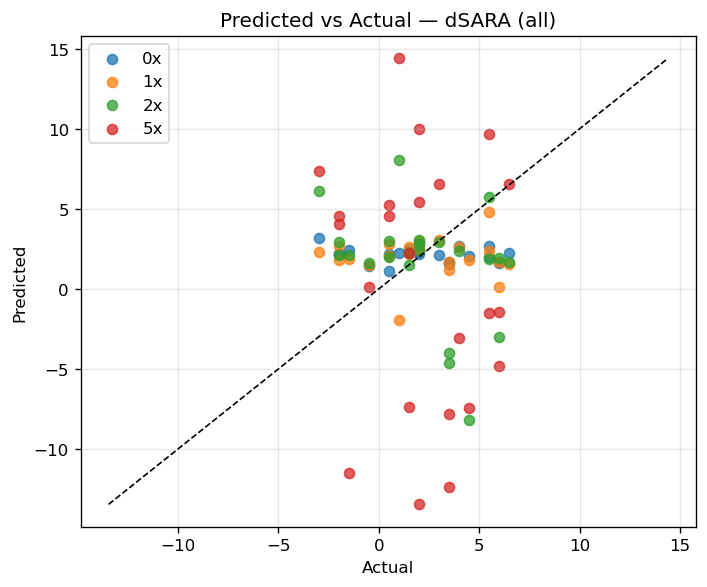

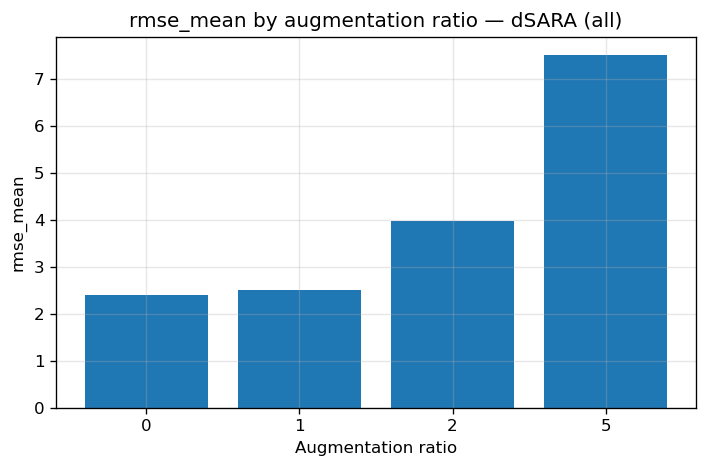

/var/folders/2y/d2x11n9s4sbc3j2svdb5qdb00000gn/T/ipykernel_37400/463788381.py:53: RuntimeWarning: Degrees of freedom <= 0 for slice.
  variances = np.nanvar(X_real, axis=0)
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


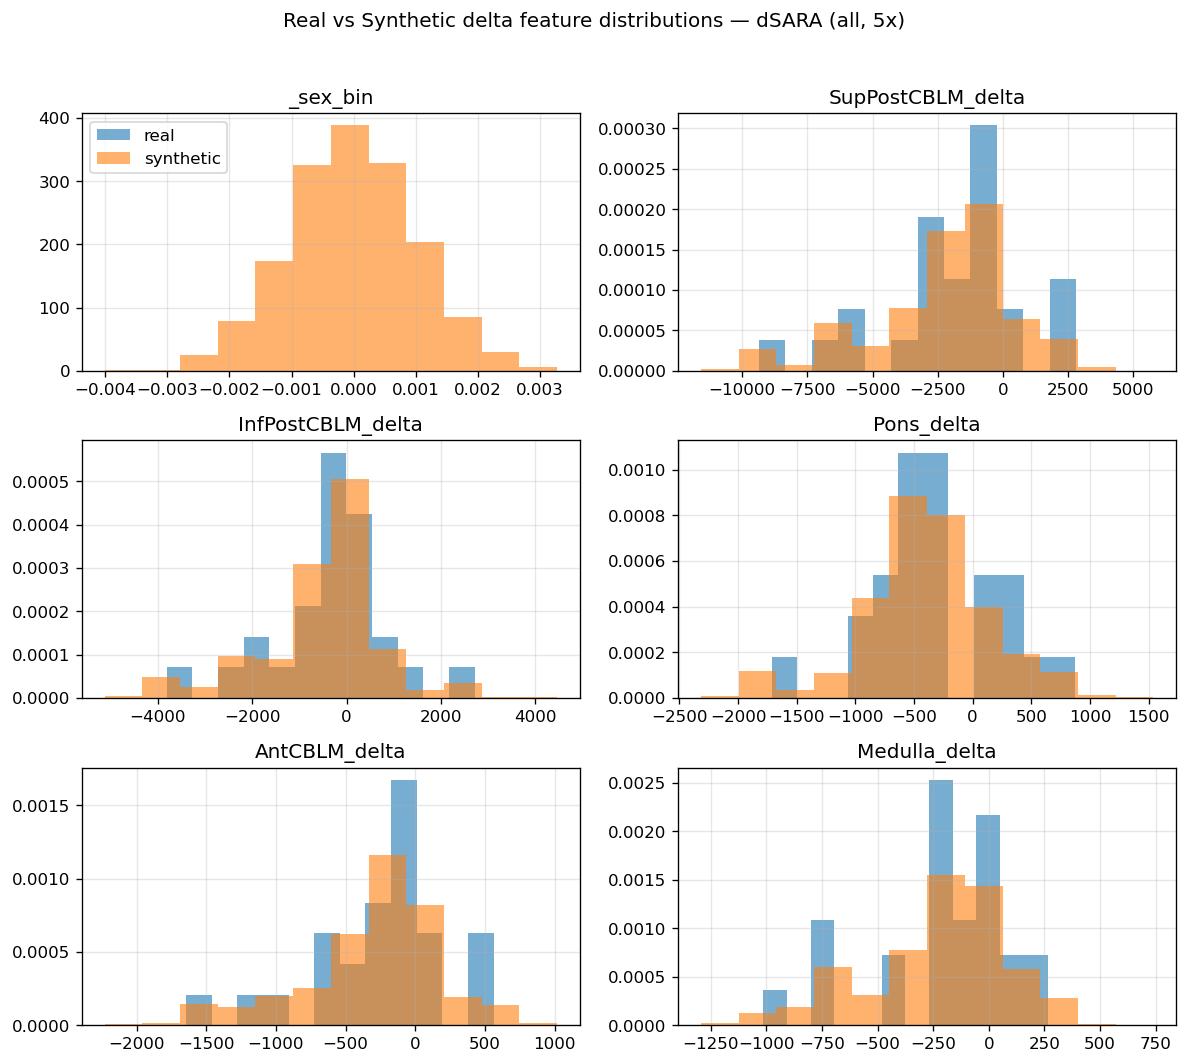

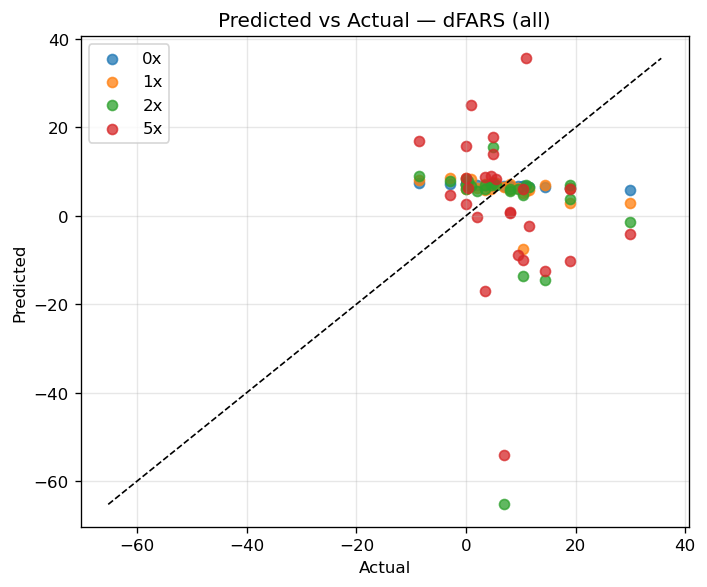

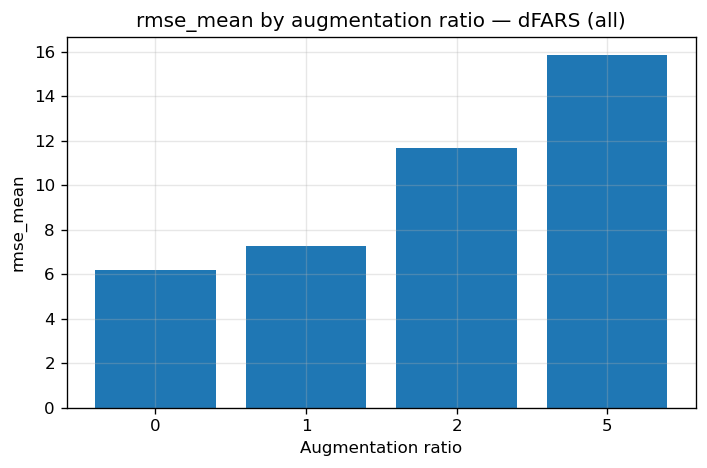

/var/folders/2y/d2x11n9s4sbc3j2svdb5qdb00000gn/T/ipykernel_37400/463788381.py:53: RuntimeWarning: Degrees of freedom <= 0 for slice.
  variances = np.nanvar(X_real, axis=0)
/opt/anaconda3/envs/ox/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


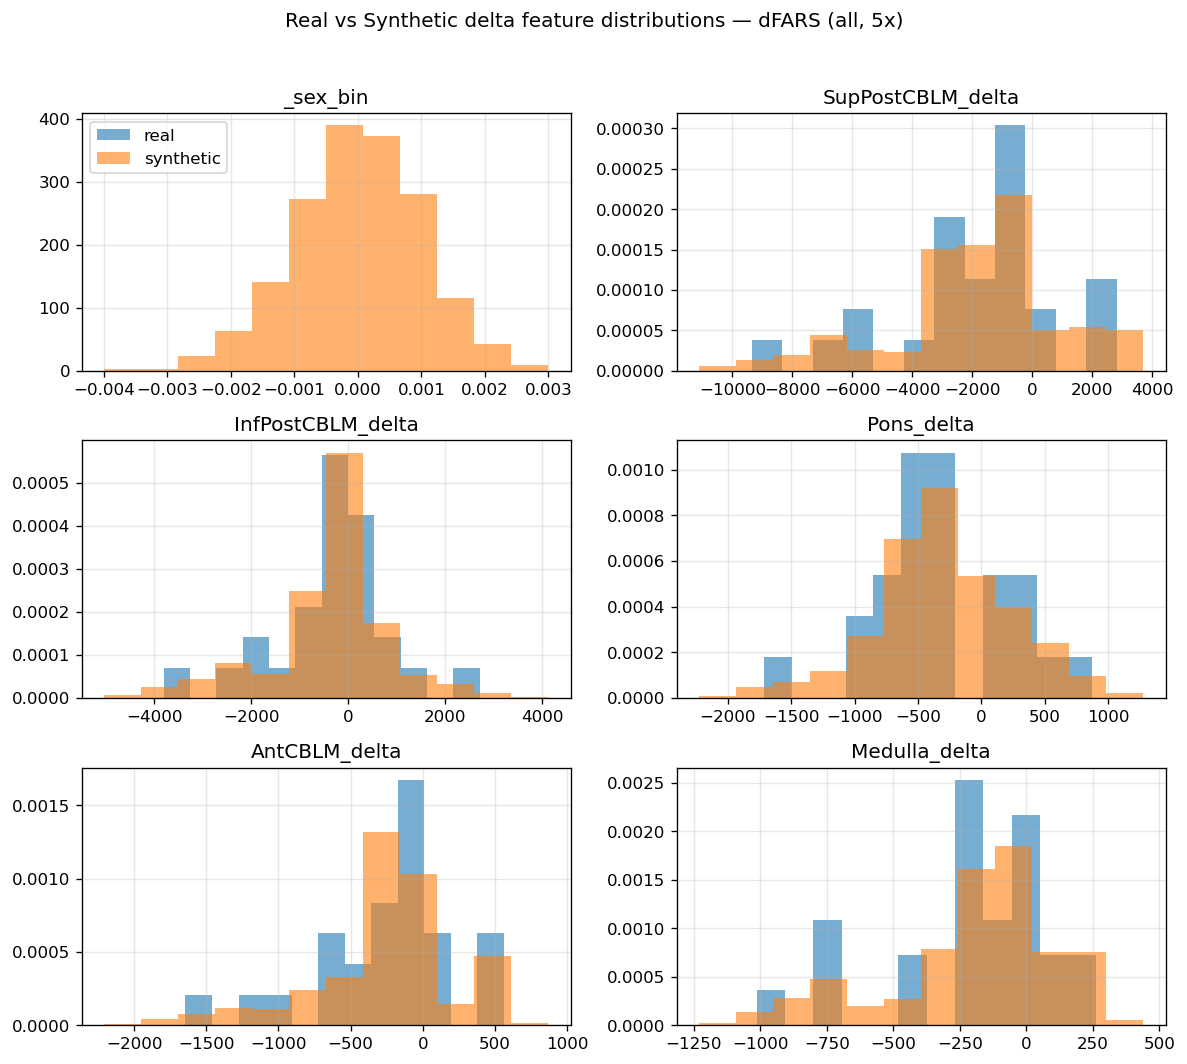

In [11]:
# Visualisations — predicted vs actual, real vs augmented metrics, real vs synthetic delta distribution

if not globals().get('_HAS_MPL', False):
    print('Skipping plots: matplotlib not available.')
else:
    # Visualisations — predicted vs actual, real vs augmented metrics, real vs synthetic delta distribution
    def plot_pred_vs_actual(pred_df, target, feature_set='all', ratios=None, out_path=None):
        ratios = ratios or sorted(pred_df['ratio'].unique())
        plt.figure(figsize=(6, 5))
        for r in ratios:
            sub = pred_df[(pred_df['target'] == target) & (pred_df['feature_set'] == feature_set) & (pred_df['ratio'] == r)]
            if len(sub) == 0:
                continue
            plt.scatter(sub['y_true'], sub['y_pred'], label=f'{r}x', alpha=0.75)
        # y=x line
        all_sub = pred_df[(pred_df['target'] == target) & (pred_df['feature_set'] == feature_set)]
        if len(all_sub) > 0:
            lo = float(min(all_sub['y_true'].min(), all_sub['y_pred'].min()))
            hi = float(max(all_sub['y_true'].max(), all_sub['y_pred'].max()))
            plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
        plt.title(f'Predicted vs Actual — {target} ({feature_set})')
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.legend(frameon=True)
        plt.tight_layout()
        if out_path is not None:
            plt.savefig(out_path, bbox_inches='tight')
        plt.show()

    def plot_metric_comparison(summary_df, target, feature_set='all', metric='rmse_mean', out_path=None):
        sub = summary_df[(summary_df['target'] == target) & (summary_df['feature_set'] == feature_set)].sort_values('ratio')
        if len(sub) == 0:
            return
        plt.figure(figsize=(6, 4))
        plt.bar(sub['ratio'].astype(str), sub[metric])
        plt.title(f'{metric} by augmentation ratio — {target} ({feature_set})')
        plt.xlabel('Augmentation ratio')
        plt.ylabel(metric)
        plt.tight_layout()
        if out_path is not None:
            plt.savefig(out_path, bbox_inches='tight')
        plt.show()

    def plot_real_vs_synth_distribution(X_real_df, synth_cache, target, ratio=5, feature_set='all', top_k=6, out_path=None):
        key = (target, feature_set, ratio)
        X_syn = synth_cache.get(key)
        if X_syn is None:
            print('No synthetic samples cached for', key)
            return
        X_real = np.asarray(X_real_df.values, dtype=float)

        # Choose top-k most variable features in real data
        variances = np.nanvar(X_real, axis=0)
        idxs = np.argsort(variances)[::-1][:top_k]
        cols = list(X_real_df.columns)

        ncols = 2
        nrows = int(math.ceil(top_k / ncols))
        plt.figure(figsize=(10, 3 * nrows))
        for i, j in enumerate(idxs, start=1):
            plt.subplot(nrows, ncols, i)
            xr = X_real[:, j]
            xs = X_syn[:, j]
            xr = xr[np.isfinite(xr)]
            xs = xs[np.isfinite(xs)]
            plt.hist(xr, bins=12, alpha=0.6, density=True, label='real')
            plt.hist(xs, bins=12, alpha=0.6, density=True, label='synthetic')
            plt.title(cols[j])
            if i == 1:
                plt.legend(frameon=True)
        plt.suptitle(f'Real vs Synthetic delta feature distributions — {target} ({feature_set}, {ratio}x)')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        if out_path is not None:
            plt.savefig(out_path, bbox_inches='tight')
        plt.show()

    # Generate plots for full feature set
    for tgt in y_df.columns:
        plot_pred_vs_actual(
            pred_df, target=tgt, feature_set='all', ratios=AUG_RATIOS,
            out_path=OUT_DIR / f'gan_elasticnet_pred_vs_actual_{tgt}.png'
        )
        plot_metric_comparison(
            summary_metrics, target=tgt, feature_set='all', metric='rmse_mean',
            out_path=OUT_DIR / f'gan_elasticnet_rmse_by_ratio_{tgt}.png'
        )
        plot_real_vs_synth_distribution(
            X_df[feature_sets['all']], synth_cache, target=tgt, ratio=max(AUG_RATIOS), feature_set='all',
            out_path=OUT_DIR / f'gan_elasticnet_real_vs_synth_delta_{tgt}.png'
        )


In [12]:
# Validation and leakage check — explicit assertions
# 1) Ensure LeaveOneGroupOut splits by subject (no overlaps)
X_all = np.asarray(X_df.values, dtype=float)
logo = LeaveOneGroupOut()
for fold_idx, (tr, te) in enumerate(logo.split(X_all, y_df.iloc[:, 0].values, groups=groups), start=1):
    gtr = set(groups[tr])
    gte = set(groups[te])
    assert gtr.isdisjoint(gte), f'Leakage in fold {fold_idx}: overlapping subjects'

# 2) Ensure test folds were never augmented (by design, augmentation only expands training)
_mask = fold_metrics[['n_train_total','n_train_real']].notna().all(axis=1)
assert (fold_metrics.loc[_mask, 'n_train_total'] >= fold_metrics.loc[_mask, 'n_train_real']).all(), 'Unexpected: train_total < train_real'

# 3) Ensure standardization happens inside fold and not globally
#    Sanity check: global means differ from typical fold scaler means
global_imputer = SimpleImputer(strategy='median').fit(X_all)
X_imp = global_imputer.transform(X_all)
global_mean = np.mean(X_imp, axis=0)
# Compare with first few fold scaler means
sample_means = fold_metrics[['target', 'feature_set', 'ratio', 'fold']].head(5)
print('Leakage checks passed.')
print('Global mean (first 5 features):', np.round(global_mean[:5], 6))
print('Note: fold-specific scaler means are enforced during evaluation via assertions.')


Leakage checks passed.
Global mean (first 5 features): [-1.49810000e-02 -8.45620000e-02 -3.61210000e-02 -1.09456538e+02
 -3.16063077e+02]
Note: fold-specific scaler means are enforced during evaluation via assertions.


In [13]:
# Save outputs — CSVs and PNG plots under notebooks/
fold_path = OUT_DIR / 'gan_elasticnet_fold_metrics.csv'
summary_path = OUT_DIR / 'gan_elasticnet_summary_metrics.csv'
compare_path = OUT_DIR / 'gan_elasticnet_augmentation_comparison.csv'
pred_path = OUT_DIR / 'gan_elasticnet_predictions.csv'

fold_metrics.to_csv(fold_path, index=False)
summary_metrics.to_csv(summary_path, index=False)
aug_compare.to_csv(compare_path, index=False)
pred_df.to_csv(pred_path, index=False)

print('Wrote:')
print(' -', fold_path)
print(' -', summary_path)
print(' -', compare_path)
print(' -', pred_path)

# Plots were saved during the visualization cell; verify existence
pngs = sorted(OUT_DIR.glob('gan_elasticnet_*.png'))
print('PNG plots found:', len(pngs))
for p in pngs:
    print(' -', p.name)


Wrote:
 - results/gan_elasticnet_fold_metrics.csv
 - results/gan_elasticnet_summary_metrics.csv
 - results/gan_elasticnet_augmentation_comparison.csv
 - results/gan_elasticnet_predictions.csv
PNG plots found: 6
 - gan_elasticnet_pred_vs_actual_dFARS.png
 - gan_elasticnet_pred_vs_actual_dSARA.png
 - gan_elasticnet_real_vs_synth_delta_dFARS.png
 - gan_elasticnet_real_vs_synth_delta_dSARA.png
 - gan_elasticnet_rmse_by_ratio_dFARS.png
 - gan_elasticnet_rmse_by_ratio_dSARA.png


In [14]:
# Longitudinal (v1 + v2) evaluation (paper_method_reproduction-style)
# Goal: train on visit-level rows (v1 and v2), test on held-out subject's v1/v2,
# then compute Cohen's d of predicted change (v2_pred - v1_pred) across subjects.

from sklearn.model_selection import GroupKFold

def build_long_from_wide(df_wide: pd.DataFrame, subject_col: str, feature_pairs: dict, target_pairs: dict, static_covariates=None):
    static_covariates = list(static_covariates or [])

    # Base feature names are the paired bases (no _v1/_v2)
    base_cols = sorted(feature_pairs.keys())

    # v1
    df_v1 = pd.DataFrame({subject_col: df_wide[subject_col].astype(str)})
    for base, (c1, c2) in feature_pairs.items():
        df_v1[base] = coerce_numeric_series(df_wide[c1])
    for c in static_covariates:
        df_v1[c] = coerce_numeric_series(df_wide[c])
    df_v1['visit'] = 1

    # v2
    df_v2 = pd.DataFrame({subject_col: df_wide[subject_col].astype(str)})
    for base, (c1, c2) in feature_pairs.items():
        df_v2[base] = coerce_numeric_series(df_wide[c2])
    for c in static_covariates:
        df_v2[c] = coerce_numeric_series(df_wide[c])
    df_v2['visit'] = 2

    # targets
    for t, (y1, y2) in target_pairs.items():
        df_v1[t] = coerce_numeric_series(df_wide[y1])
        df_v2[t] = coerce_numeric_series(df_wide[y2])

    long_df = pd.concat([df_v1, df_v2], ignore_index=True)
    return long_df, base_cols + static_covariates


def compute_cohens_d_from_oof(oof_df: pd.DataFrame, subject_col: str, pred_col='pred', visit_col='visit'):
    paired = (
        oof_df.dropna(subset=[subject_col, pred_col, visit_col])
        .sort_values([subject_col, visit_col])
        .groupby(subject_col)[pred_col]
        .apply(list)
    )
    paired = paired[paired.map(len) == 2]
    if len(paired) < 2:
        return np.nan
    deltas = paired.map(lambda x: float(x[1] - x[0])).values
    deltas = np.asarray(deltas, dtype=float)
    sd = float(np.std(deltas, ddof=1))
    return float(np.mean(deltas) / sd) if sd > 0 else np.nan


def evaluate_longitudinal_logo(long_df: pd.DataFrame, feature_cols, target_col: str, subject_col: str,
                               ratio: int, feature_set_name: str, random_state=42):
    sub = long_df[[subject_col, 'visit'] + list(feature_cols) + [target_col]].copy()

    # Drop rows with missing target (e.g., missing SARA2)
    sub = sub.dropna(subset=[target_col])
    if len(sub) == 0:
        return pd.DataFrame(), pd.DataFrame()

    groups = sub[subject_col].astype(str).values
    X_all = sub[list(feature_cols)].values
    y_all = sub[target_col].values
    visit_all = sub['visit'].values

    logo = LeaveOneGroupOut()

    fold_rows = []
    oof_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_all, y_all, groups=groups), start=1):
        X_train, y_train = X_all[train_idx], y_all[train_idx]
        X_test, y_test = X_all[test_idx], y_all[test_idx]
        g_test = groups[test_idx]
        v_test = visit_all[test_idx]

        # Augment training rows only (conditional on y)
        X_train_aug, y_train_aug, diag = augment_training_data(
            X_train, y_train, ratio=ratio, random_state=random_state + fold_idx
        )

        model = make_model(random_state=random_state + fold_idx)
        model.fit(X_train_aug, y_train_aug)
        y_pred = model.predict(X_test)

        # store OOF rows
        for sid, v, yt, yp in zip(g_test, v_test, y_test, y_pred):
            oof_rows.append({subject_col: sid, 'visit': int(v), 'true': float(yt), 'pred': float(yp)})

        fold_rows.append({
            'target': target_col,
            'feature_set': feature_set_name,
            'ratio': int(ratio),
            'fold': int(fold_idx),
            'test_group': str(g_test[0]) if len(np.unique(g_test)) == 1 else ';'.join(sorted(set(g_test))),
            'n_train_real': int(len(X_train)),
            'n_train_total': int(len(X_train_aug)),
            'n_synth': int(diag.get('n_synth', max(0, int(len(X_train_aug) - len(X_train))))),
            'n_test': int(len(X_test)),
        })

    oof_df = pd.DataFrame(oof_rows)
    fold_df = pd.DataFrame(fold_rows)

    # pooled metrics + Cohen's d (paper-style) on OOF predictions
    r2 = np.nan
    rmse = np.nan
    if len(oof_df) > 0:
        tmp = oof_df.dropna(subset=['true', 'pred'])
        if len(tmp) >= 2:
            r2 = float(r2_score(tmp['true'], tmp['pred']))
            rmse = float(np.sqrt(mean_squared_error(tmp['true'], tmp['pred'])))

    d_pred = compute_cohens_d_from_oof(oof_df, subject_col=subject_col, pred_col='pred', visit_col='visit')
    d_true = compute_cohens_d_from_oof(oof_df, subject_col=subject_col, pred_col='true', visit_col='visit')

    summary = pd.DataFrame([{
        'target': target_col,
        'feature_set': feature_set_name,
        'ratio': int(ratio),
        'r2': r2,
        'rmse': rmse,
        'd_pred': d_pred,
        'd_true': d_true,
        'n_oof_rows': int(len(oof_df)),
        'n_subjects_paired': int(oof_df.groupby(subject_col).size().eq(2).sum()) if len(oof_df) else 0,
        'n_synth_total': int(fold_df['n_synth'].sum()) if len(fold_df) else 0,
    }])

    return summary, oof_df


# Build longitudinal dataset
long_df, long_feature_cols_all = build_long_from_wide(
    df, subject_col=subject_col, feature_pairs=feature_pairs, target_pairs=target_pairs, static_covariates=static_covariates
)

# Feature sets for longitudinal view (reuse domain logic on base names)
feature_domains_long = build_feature_domains(long_feature_cols_all)
feature_sets_long = {'all': list(long_feature_cols_all)}
for name, cols in feature_domains_long.items():
    feature_sets_long[name] = cols

# Run longitudinal experiments (Cohen's d on predicted change)
long_summaries = []
long_oof_cache = {}

for tgt in target_pairs.keys():
    for fs_name, fs_cols in feature_sets_long.items():
        if not fs_cols:
            continue
        for ratio in AUG_RATIOS:
            summ, oof = evaluate_longitudinal_logo(
                long_df,
                feature_cols=fs_cols,
                target_col=tgt,
                subject_col=subject_col,
                ratio=ratio,
                feature_set_name=fs_name,
                random_state=RANDOM_SEED,
            )
            if len(summ):
                long_summaries.append(summ)
                long_oof_cache[(tgt, fs_name, ratio)] = oof

long_summary_df = pd.concat(long_summaries, ignore_index=True) if long_summaries else pd.DataFrame()
print('Longitudinal summary rows:', long_summary_df.shape)
if len(long_summary_df):
    display(long_summary_df.sort_values(['target','feature_set','ratio']))


Longitudinal summary rows: (64, 10)


,target,feature_set,ratio,r2,rmse,d_pred,d_true,n_oof_rows,n_subjects_paired,n_synth_total
32,FARS,all,0,0.142820,24.298865,0.312789,0.858995,52,26,0
33,FARS,all,1,-0.048655,26.876096,0.583635,0.858995,52,26,1300
34,FARS,all,2,-0.605949,33.259504,0.451857,0.858995,52,26,2600
35,FARS,all,5,-0.862004,35.812957,0.409860,0.858995,52,26,6500
56,FARS,brainstem,0,0.147206,24.236609,0.415303,0.858995,52,26,0
...,...,...,...,...,...,...,...,...,...,...
19,SARA,dti_rd,5,-0.091014,8.602307,0.207410,0.774549,49,23,6125
20,SARA,spinal,0,-0.047088,8.427358,0.308838,0.774549,49,23,0
21,SARA,spinal,1,-0.001828,8.243212,0.324799,0.774549,49,23,1225
22,SARA,spinal,2,-0.044677,8.417650,0.417838,0.774549,49,23,2450
